In [14]:
import numpy as np

In [2]:
import os
from sqlalchemy import create_engine
import pandas as pd

# Set DATABASE_URI
os.environ["DATABASE_URI"] = "postgresql+psycopg2://rirg2545@localhost/eicu"

# Create engine
engine = create_engine(
    os.environ["DATABASE_URI"],
    echo=False,
    future=True,
    pool_pre_ping=True
)

# Query using normalized MAP table (NO CSV parsing anymore)
query_context_only = """
SELECT
    w.patientunitstayid,
    w.context_start_offset_min,
    w.context_end_offset_min,
    c.infusionoffset AS treatment_starttime,
    last_map.offset AS last_map_absolute_offset,
    last_map.valuenum AS last_map_before_treatment

FROM public.all_labeled_windows w

-- pick the correct infusion AFTER the context window
JOIN LATERAL (
    SELECT infusionoffset
    FROM public.catecholamine_events_4h c
    WHERE c.patientunitstayid = w.patientunitstayid
      AND c.infusionoffset > w.context_start_offset_min
    ORDER BY infusionoffset
    LIMIT 1
) c ON TRUE

-- now pick closest MAP before that infusion
JOIN LATERAL (
    SELECT ma.offset, ma.valuenum
    FROM public.filtered_maps ma
    WHERE ma.patientunitstayid = w.patientunitstayid
      AND ma.offset BETWEEN w.context_start_offset_min
                        AND w.context_end_offset_min
      AND ma.offset < c.infusionoffset
    ORDER BY ma.offset DESC
    LIMIT 1
) last_map ON TRUE

WHERE w.positive_event;
"""

# Execute query
df_context_only = pd.read_sql(query_context_only, engine)

print(df_context_only.head())

   patientunitstayid  context_start_offset_min  context_end_offset_min  \
0             242040                       330                     450   
1             242082                      1140                    1260   
2             243334                       885                    1005   
3             243334                      2505                    2625   
4             243334                      3165                    3285   

   treatment_starttime  last_map_absolute_offset  last_map_before_treatment  
0                  457                       397                       87.0  
1                 1265                      1235                       64.0  
2                 1010                      1001                       68.0  
3                 2630                      2621                       84.0  
4                 3290                      3281                       51.0  


In [10]:
df_context_only['last_map_difference']= df_context_only['treatment_starttime'] - df_context_only['last_map_absolute_offset']

df_context_only['last_map_difference'].median()

np.float64(13.0)

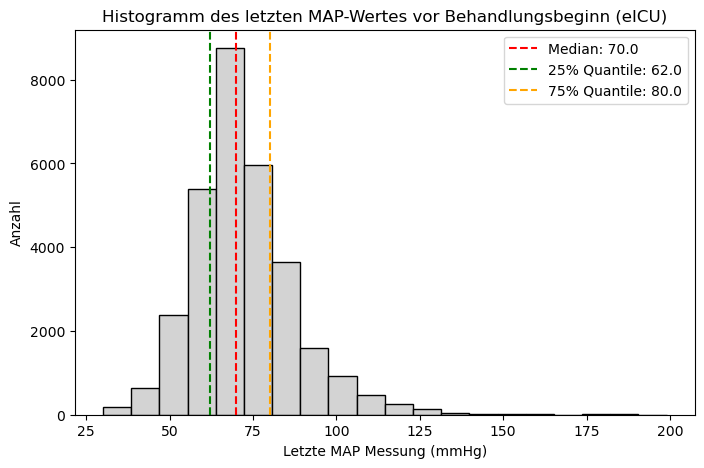

In [12]:

# Compute statistics
import matplotlib.pyplot as plt

n_total = len(df_context_only)
median = df_context_only['last_map_before_treatment'].median()
q25 = df_context_only['last_map_before_treatment'].quantile(0.25)
q75 = df_context_only['last_map_before_treatment'].quantile(0.75)

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(df_context_only['last_map_before_treatment'], bins=20, color='lightgrey', edgecolor='black')
plt.xlabel("Letzte MAP Messung (mmHg)")
plt.ylabel("Anzahl")
plt.title("Histogramm des letzten MAP-Wertes vor Behandlungsbeginn (eICU)")

# Add vertical lines
plt.axvline(median, color='red', linestyle='--', label=f'Median: {median:.1f}')
plt.axvline(q25, color='green', linestyle='--', label=f'25% Quantile: {q25:.1f}')
plt.axvline(q75, color='orange', linestyle='--', label=f'75% Quantile: {q75:.1f}')

# Add counts to legend
plt.legend()
plt.savefig("histogram_last_map_eicu.pdf")
plt.show()


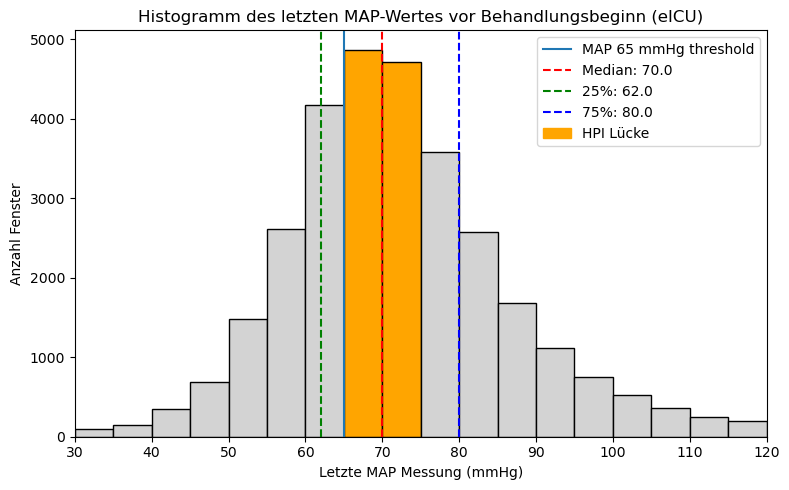

In [19]:
import numpy as np
import matplotlib.pyplot as plt

n_total = len(df_context_only)
median = df_context_only['last_map_before_treatment'].median()
q25 = df_context_only['last_map_before_treatment'].quantile(0.25)
q75 = df_context_only['last_map_before_treatment'].quantile(0.75)

plt.figure(figsize=(8,5))

# Define bins
xmin = 30
xmax = 120
bin_width = 5
bins = np.arange(xmin, xmax + bin_width, bin_width)

# Compute histogram manually to set colors
counts, bin_edges = np.histogram(df_context_only['last_map_before_treatment'], bins=bins)

# Define colors: default gray, highlight 65–75
colors = []
for left, right in zip(bin_edges[:-1], bin_edges[1:]):
    if left >= 65 and right <= 75:
        colors.append('orange')  # color for HPI Lücke
    else:
        colors.append('lightgray')  # default color

# Plot bars with individual colors
plt.bar(bin_edges[:-1], counts, width=bin_width, align='edge', edgecolor='black', color=colors)

# Add clinical threshold line
plt.axvline(65, linestyle='-', label='MAP 65 mmHg threshold')

# Add distribution lines
plt.axvline(median, color='red', linestyle='--', label=f'Median: {median:.1f}')
plt.axvline(q25, color='green', linestyle='--', label=f'25%: {q25:.1f}')
plt.axvline(q75, color='blue', linestyle='--', label=f'75%: {q75:.1f}')

# Add custom legend for highlighted range
import matplotlib.patches as mpatches
hpi_patch = mpatches.Patch(color='orange', label='HPI Lücke')
plt.legend(handles=plt.gca().get_legend_handles_labels()[0] + [hpi_patch])

# Axis formatting
plt.xlim(xmin, xmax)
plt.xticks(np.arange(xmin, xmax+1, 10))
plt.xlabel("Letzte MAP Messung (mmHg)")
plt.ylabel("Anzahl Fenster")
plt.title("Histogramm des letzten MAP-Wertes vor Behandlungsbeginn (eICU)")

plt.tight_layout()
plt.savefig("histogram_last_map_slide_ready.pdf")
plt.show()

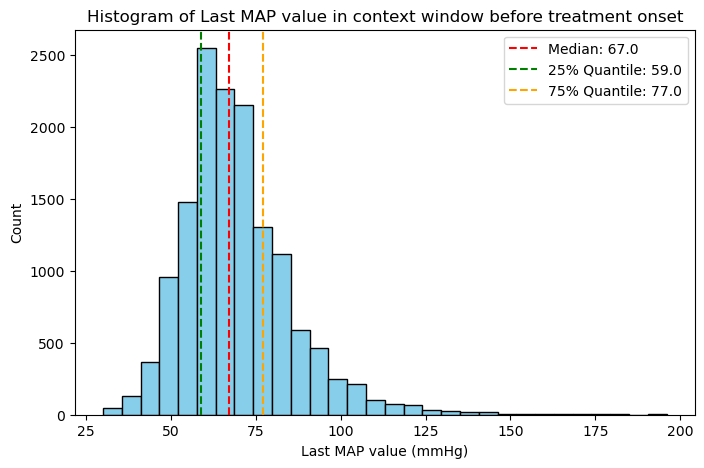

In [42]:
# Compute statistics
median = df_context_only['last_map'].median()
q25 = df_context_only['last_map'].quantile(0.25)
q75 = df_context_only['last_map'].quantile(0.75)

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(df_context_only['last_map'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Last MAP value (mmHg)")
plt.ylabel("Count")
plt.title("Histogram of Last MAP value in context window before treatment onset")

# Add vertical lines
plt.axvline(median, color='red', linestyle='--', label=f'Median: {median:.1f}')
plt.axvline(q25, color='green', linestyle='--', label=f'25% Quantile: {q25:.1f}')
plt.axvline(q75, color='orange', linestyle='--', label=f'75% Quantile: {q75:.1f}')

plt.legend()
plt.show()